# Texas Football Data Science Starter Project

Uses the [CollegeFootballData.com](https://collegefootballdata.com) (CFBD) API to pull Texas Longhorns stats and do exploratory data analysis.

**Setup:**
1. Get a free API key at [collegefootballdata.com/key](https://collegefootballdata.com/key)
2. `pip install cfbd pandas matplotlib seaborn scikit-learn`
3. Paste your API key in the config cell below
4. Run the cells in order

## Imports & Configuration

In [1]:
import cfbd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
import re as _re
def to_snake_case(name):
    s1 = _re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return _re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()
def snake_df(df):
    return df.rename(columns={c: to_snake_case(c) for c in df.columns})


In [2]:
import os
# =============================================================================
# CONFIG - paste your CFBD API key here
# =============================================================================
API_KEY = os.environ["CFBD_API_KEY"]

TEAM = "Texas"
YEARS = range(2015, 2026)  # 10+ seasons of data

configuration = cfbd.Configuration(access_token=API_KEY)

## 1. Pull Game-Level Data

Pulls all Texas games for the specified year range from the CFBD API.

In [3]:
def get_texas_games(years=YEARS):
    """Pull all Texas games for the specified year range."""
    all_games = []

    with cfbd.ApiClient(configuration) as api_client:
        games_api = cfbd.GamesApi(api_client)

        for year in years:
            try:
                games = games_api.get_games(year=year, team=TEAM)
                for g in games:
                    all_games.append(g.to_dict())
                print(f"  {year}: {len(games)} games")
            except Exception as e:
                print(f"  {year}: error - {e}")

    df = snake_df(pd.DataFrame(all_games))
    return df

In [4]:
print("=" * 60)
print("PULLING TEXAS GAME DATA")
print("=" * 60)
games_df = get_texas_games()
print(f"\nTotal games pulled: {len(games_df)}")
print(f"Columns: {list(games_df.columns)}")

PULLING TEXAS GAME DATA


  2015: 12 games
  2016: 12 games


  2017: 13 games
  2018: 14 games


  2019: 13 games


  2020: 10 games
  2021: 12 games


  2022: 13 games
  2023: 14 games


  2024: 16 games
  2025: 13 games

Total games pulled: 142
Columns: ['id', 'season', 'week', 'season_type', 'start_date', 'start_time_tbd', 'completed', 'neutral_site', 'conference_game', 'attendance', 'venue_id', 'venue', 'home_id', 'home_team', 'home_conference', 'home_classification', 'home_points', 'home_line_scores', 'home_postgame_win_probability', 'home_pregame_elo', 'home_postgame_elo', 'away_id', 'away_team', 'away_conference', 'away_classification', 'away_points', 'away_line_scores', 'away_postgame_win_probability', 'away_pregame_elo', 'away_postgame_elo', 'excitement_index', 'highlights', 'notes']


## 2. Feature Engineering

Derives Texas points, opponent points, margin, win/loss flag, home/away indicator, and opponent name from the raw game records.

In [5]:
def engineer_features(df):
    """
    Add useful columns: Texas score, opponent score, margin, home/away flag,
    win/loss indicator, etc.
    """
    df = df.copy()

    # Determine if Texas was home or away
    df["texas_is_home"] = df["home_team"] == TEAM

    # Texas points and opponent points
    df["texas_points"] = df.apply(
        lambda r: r["home_points"] if r["texas_is_home"] else r["away_points"],
        axis=1,
    )
    df["opp_points"] = df.apply(
        lambda r: r["away_points"] if r["texas_is_home"] else r["home_points"],
        axis=1,
    )
    df["opponent"] = df.apply(
        lambda r: r["away_team"] if r["texas_is_home"] else r["home_team"],
        axis=1,
    )

    # Margin and result
    df["margin"] = df["texas_points"] - df["opp_points"]
    df["win"] = (df["margin"] > 0).astype(int)
    df["total_points"] = df["texas_points"] + df["opp_points"]

    # Season and week for grouping
    df["season"] = df["season"].astype(int)
    df["week"] = df["week"].astype(int)

    return df

In [6]:
games_df = engineer_features(games_df)

print("Sample of engineered data:")
games_df[["season", "week", "opponent", "texas_points", "opp_points", "margin", "win"]].head(10)

Sample of engineered data:


,season,week,opponent,texas_points,opp_points,margin,win
0,2015,1,Notre Dame,3,38,-35,0
1,2015,2,Rice,42,28,14,1
2,2015,3,California,44,45,-1,0
3,2015,4,Oklahoma State,27,30,-3,0
4,2015,5,TCU,7,50,-43,0
5,2015,6,Oklahoma,24,17,7,1
6,2015,8,Kansas State,23,9,14,1
7,2015,9,Iowa State,0,24,-24,0
8,2015,10,Kansas,59,20,39,1
9,2015,11,West Virginia,20,38,-18,0


## 3. Season Summary Table

Aggregates wins, losses, win percentage, average points scored/allowed, and average margin by season.

In [7]:
season_summary = (
    games_df.groupby("season")
    .agg(
        games=("win", "count"),
        wins=("win", "sum"),
        avg_texas_pts=("texas_points", "mean"),
        avg_opp_pts=("opp_points", "mean"),
        avg_margin=("margin", "mean"),
    )
    .reset_index()
)
season_summary["losses"] = season_summary["games"] - season_summary["wins"]
season_summary["win_pct"] = (season_summary["wins"] / season_summary["games"]).round(3)

season_summary

,season,games,wins,avg_texas_pts,avg_opp_pts,avg_margin,losses,win_pct
0,2015,12,5,26.416667,30.333333,-3.916667,7,0.417
1,2016,12,5,31.916667,31.500000,0.416667,7,0.417
2,2017,13,7,29.461538,21.230769,8.230769,6,0.538
3,2018,14,10,31.071429,25.857143,5.214286,4,0.714
4,2019,13,8,35.230769,27.461538,7.769231,5,0.615
5,2020,10,7,42.700000,28.500000,14.200000,3,0.700
6,2021,12,5,35.250000,31.083333,4.166667,7,0.417
7,2022,13,8,34.461538,21.615385,12.846154,5,0.615
8,2023,14,12,35.785714,18.928571,16.857143,2,0.857
9,2024,16,13,33.000000,15.312500,17.687500,3,0.812


## 4. Visualizations

Four-panel chart in Texas purple and gold showing:
- Win percentage by season
- Scoring trends over time
- Distribution of game margins
- Home vs. away win rates

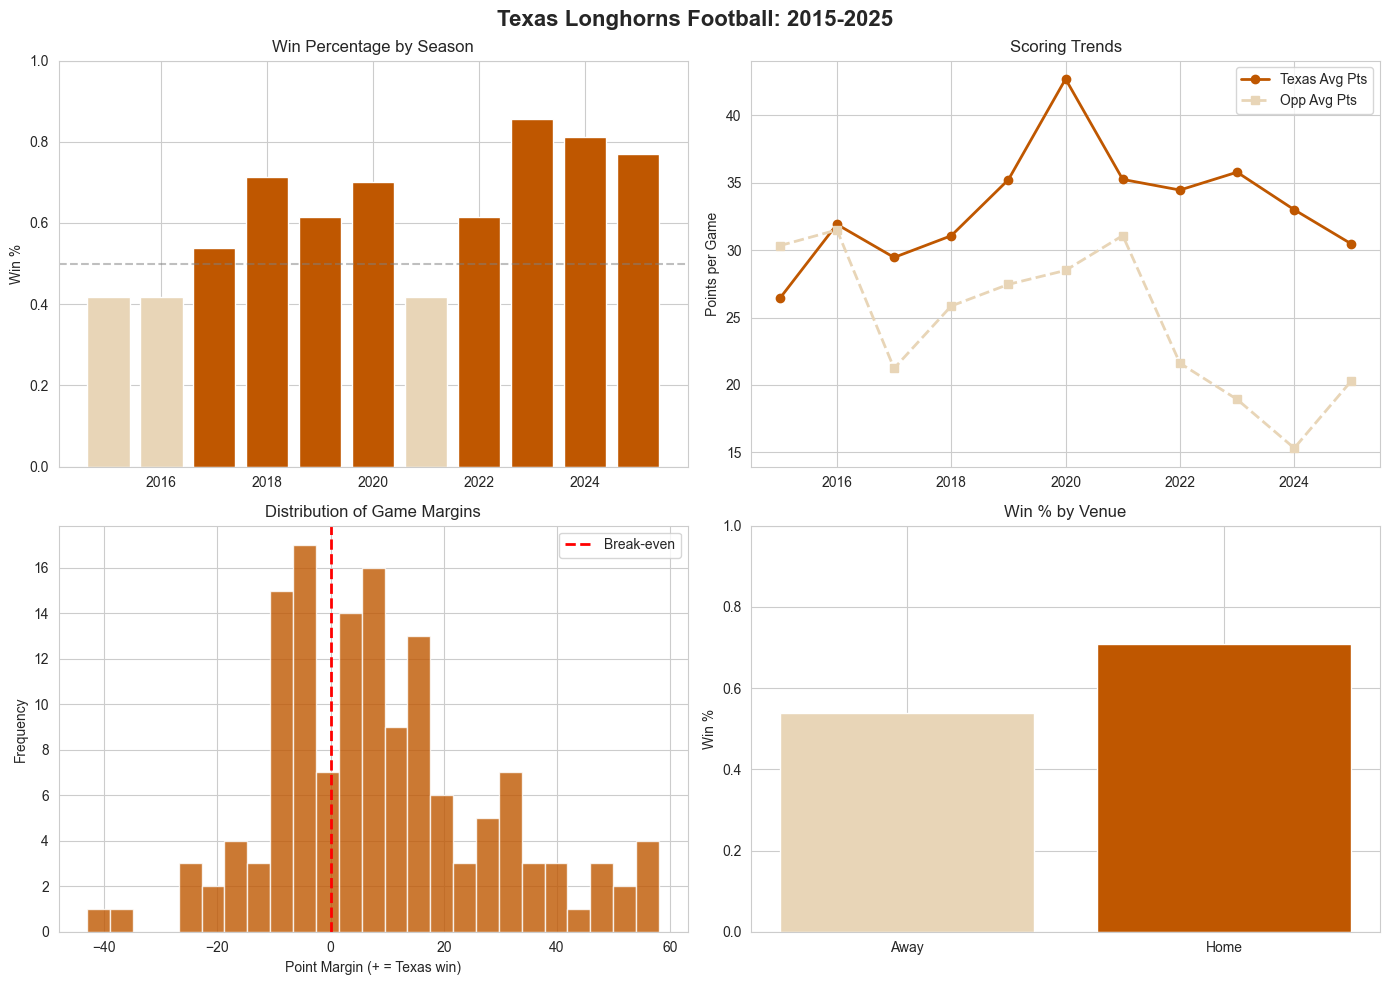

Chart saved to texas_football_eda.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Texas Longhorns Football: 2015-2025", fontsize=16, fontweight="bold")

# Plot 1: Win percentage by season
ax1 = axes[0, 0]
colors = ["#BF5700" if wp >= 0.5 else "#E8D5B7" for wp in season_summary["win_pct"]]
ax1.bar(season_summary["season"], season_summary["win_pct"], color=colors, edgecolor="white")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax1.set_title("Win Percentage by Season")
ax1.set_ylabel("Win %")
ax1.set_ylim(0, 1)

# Plot 2: Points scored vs allowed by season
ax2 = axes[0, 1]
ax2.plot(
    season_summary["season"],
    season_summary["avg_texas_pts"],
    "o-",
    color="#BF5700",
    label="Texas Avg Pts",
    linewidth=2,
)
ax2.plot(
    season_summary["season"],
    season_summary["avg_opp_pts"],
    "s--",
    color="#E8D5B7",
    label="Opp Avg Pts",
    linewidth=2,
)
ax2.set_title("Scoring Trends")
ax2.set_ylabel("Points per Game")
ax2.legend()

# Plot 3: Distribution of margins
ax3 = axes[1, 0]
ax3.hist(
    games_df["margin"],
    bins=25,
    color="#BF5700",
    edgecolor="white",
    alpha=0.8,
)
ax3.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Break-even")
ax3.set_title("Distribution of Game Margins")
ax3.set_xlabel("Point Margin (+ = Texas win)")
ax3.set_ylabel("Frequency")
ax3.legend()

# Plot 4: Home vs Away performance
ax4 = axes[1, 1]
home_away = (
    games_df.groupby("texas_is_home")
    .agg(win_pct=("win", "mean"), avg_margin=("margin", "mean"))
    .reset_index()
)
home_away["label"] = home_away["texas_is_home"].map({True: "Home", False: "Away"})
ax4.bar(home_away["label"], home_away["win_pct"], color=["#E8D5B7", "#BF5700"], edgecolor="white")
ax4.set_title("Win % by Venue")
ax4.set_ylabel("Win %")
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("texas_football_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to texas_football_eda.png")

## 5. Pull Detailed Team Stats (Optional)

Per-game team stats for deeper analysis. Uncomment the call to execute.

In [9]:
def get_texas_team_stats(years=YEARS):
    """Pull per-game team stats for Texas."""
    all_stats = []

    with cfbd.ApiClient(configuration) as api_client:
        stats_api = cfbd.GamesApi(api_client)

        for year in years:
            try:
                stats = stats_api.get_game_team_stats(year=year, team=TEAM)
                for game in stats:
                    game_dict = game.to_dict()
                    all_stats.append(game_dict)
            except Exception as e:
                print(f"  {year} stats error: {e}")

    return all_stats

# Uncomment below to pull detailed stats (uses more API calls)
# team_stats = get_texas_team_stats()
# print(f"Pulled stats for {len(team_stats)} games")

## 6. Pull Recruiting Data (Optional)

Texas recruiting class ratings. Uncomment the call to execute.

In [10]:
def get_texas_recruiting(years=YEARS):
    """Pull Texas recruiting class ratings."""
    all_recruiting = []

    with cfbd.ApiClient(configuration) as api_client:
        recruiting_api = cfbd.RecruitingApi(api_client)

        for year in years:
            try:
                classes = recruiting_api.get_recruiting_teams(year=year, team=TEAM)
                for c in classes:
                    all_recruiting.append(c.to_dict())
            except Exception as e:
                print(f"  {year} recruiting error: {e}")

    return snake_df(pd.DataFrame(all_recruiting))

# Uncomment below to pull recruiting data
# recruiting_df = get_texas_recruiting()
# recruiting_df[["year", "rank", "points"]]

## 7. Simple Predictive Model

A naive GradientBoosting classifier predicting win/loss from season, week, and home/away. Intentionally basic — the real value comes from enriching with recruiting rankings, opponent strength, betting lines, etc.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Build a simple win/loss classifier from available game-level features
model_df = games_df[["season", "week", "texas_is_home", "win"]].dropna()
model_df["texas_is_home"] = model_df["texas_is_home"].astype(int)

X = model_df[["season", "week", "texas_is_home"]]
y = model_df["win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Naive model accuracy: {accuracy:.1%}")
print("(This baseline uses only season, week, and home/away.)")
print(f"\nFeature importances:")
for feat, imp in zip(X.columns, clf.feature_importances_):
    print(f"  {feat:15s}: {imp:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Loss", "Win"]))

Naive model accuracy: 52.8%
(This baseline uses only season, week, and home/away.)

Feature importances:
  season         : 0.409
  week           : 0.516
  texas_is_home  : 0.075

Classification Report:
              precision    recall  f1-score   support

        Loss       0.36      0.38      0.37        13
         Win       0.64      0.61      0.62        23

    accuracy                           0.53        36
   macro avg       0.50      0.50      0.50        36
weighted avg       0.54      0.53      0.53        36



## Project Ideas for Deeper Analysis

1. **Win Probability Model** — Pull play-by-play data, build a live win probability model. Features: score differential, time remaining, field position, down/distance.

2. **Recruiting vs. Performance** — Correlate recruiting class rank/points with wins 2-3 years later. Which position groups matter most?

3. **Opponent-Adjusted Metrics** — Use SP+ or SRS ratings to adjust raw stats. How does Texas perform vs. top-25 opponents vs. the rest?

4. **Betting Market Analysis** — Pull historical betting lines from the API. Has Texas been a profitable ATS bet? Under/over trends?

5. **Coaching Impact** — Compare offensive/defensive efficiency across coaching eras (Herman, Sarkisian, etc.)